#  TP noté — Titanic : aller plus loin avec les DataFrames

**Cours :** Introduction à la Data Science  
**Sujet :** Analyse exploratoire avancée et premières transformations sur le dataset Titanic  
**Barème :** /5 points  

Dans ce TP, vous allez :

- Approfondir l'exploration du dataset Titanic  
- Nettoyer et transformer quelques variables  
- Analyser la survie selon plusieurs critères  
- Produire des visualisations un peu plus riches  
- Rédiger une courte interprétation des résultats  

>  Ce TP suppose que vous avez déjà vu les bases de `pandas` et un premier notebook d'introduction sur Titanic.


##  Objectifs du TP

À la fin de ce TP, vous devrez être capables de :

- Gérer des valeurs manquantes de façon raisonnable  
- Créer de nouvelles colonnes à partir des données existantes (feature engineering simple)  
- Utiliser `groupby` pour faire des analyses par groupe  
- Construire des visualisations combinant plusieurs variables  
- Interpréter vos résultats de manière concise


## 1 Import des bibliothèques

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Bibliothèques importées.")

Bibliothèques importées.


## 2 Chargement du dataset Titanic

 Nous chargeons de nouveau le dataset depuis une URL publique.  
Vous pouvez adapter ce code si vous avez un fichier local (`data/titanic.csv`).

In [49]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3 Nettoyage basique des données

### Exercice 1

1. Affichez le nombre de valeurs manquantes pour chaque colonne.  
2. Identifiez au moins **deux colonnes** problématiques.

➡️ Indice : utilisez `df.isna().sum()`.


In [50]:
# Exercice 1 : valeurs manquantes
# À compléter

df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


###  Exercice 2

Nous souhaitons traiter la colonne `Age` :  
1. Calculez l'âge moyen et médian.  
2. Remplacez les valeurs manquantes de `Age` par la **médiane**.  

➡️ Faites la modification directement dans `df`.


In [51]:
# Exercice 2 : traitement de la colonne Age
# À compléter
# 1) Afficher la moyenne et la médiane de Age
df['Age'].mean()
df['Age'].median()
# 2) Remplacer les NaN de Age par la médiane
df['Age'].fillna(df['Age'].median())



,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


## 4 Création de nouvelles variables

Nous allons créer une variable qui résume un peu la situation familiale à bord.

### Exercice 3

Créez une nouvelle colonne `FamilySize` définie comme :

\[ \text{FamilySize} = SibSp + Parch + 1 \]

(où 1 représente le passager lui-même)

➡️ Affichez ensuite les 5 premières lignes des colonnes `SibSp`, `Parch` et `FamilySize`.



In [52]:
# Exercice 3 : création de FamilySize
# À compléter
df['FamilySize']=df['SibSp']+df['Parch']+ 1
df[['SibSp','Parch','FamilySize']].head(5)


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


###  Exercice 4

Créez une nouvelle colonne `IsAlone` qui vaut :

- 1 si `FamilySize == 1`  
- 0 sinon

➡️ Vérifiez  la répartition de cette nouvelle variable (`value_counts()`).


In [53]:
# Exercice 4 : création de IsAlone
# À compléter
df['IsAlone']=np.where(df['FamilySize']==1,1,0)
df['IsAlone'].value_counts()


,count
IsAlone,
1,537
0,354


## 5 Analyse de la survie par groupe

### Exercice 5 (1 pt)

Calculez le **taux de survie moyen** selon :

1. le **sexe** (`Sex`)  
2. la **classe** (`Pclass`)  
3. si la personne est **seule ou non** (`IsAlone`)

 Utilisez `groupby()` suivi de `mean()` sur la colonne `Survived`.

quels groupes semblent mieux survivre ?


In [54]:
from pandas.core import groupby
# Exercice 5 : taux de survie par groupe
# À compléter
survie_Sexe=df.groupby('Sex')['Survived'].mean()
survie_Pclass=df.groupby('Pclass')['Survived'].mean()
survie_IsAlone=df.groupby('IsAlone')['Survived'].mean()
# Exemple : df.groupby("Sex")["Survived"].mean()
print(survie_Sexe)
print(survie_Pclass)
print(survie_IsAlone)


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


Concernant le sexe,les femmes survivent à 74% contre 18% pour les hommes

Les passagers de classe 1 survivent à 62% contre 47% pour les classe 2 et 24% pour les classes 3

Enfin, les passagers qui ne sont pas seuls survivent à 50% contre 30% pour ceux seuls

## 6️ Visualisations combinées

###  Exercice 6

Réalisez au moins **deux visualisations** parmi les propositions suivantes :

1. Taux de survie par sexe (barplot)  
2. Taux de survie par classe (`Pclass`)  
3. Taux de survie selon `IsAlone`  
4. Boxplot de l'âge selon la classe (`Pclass`)  
5. Heatmap de corrélation sur un sous-ensemble de colonnes numériques

Utilisez `seaborn` (`sns.barplot`, `sns.boxplot`, `sns.heatmap`, etc.).  
Ajoutez un `plt.title()` à chaque graphique.


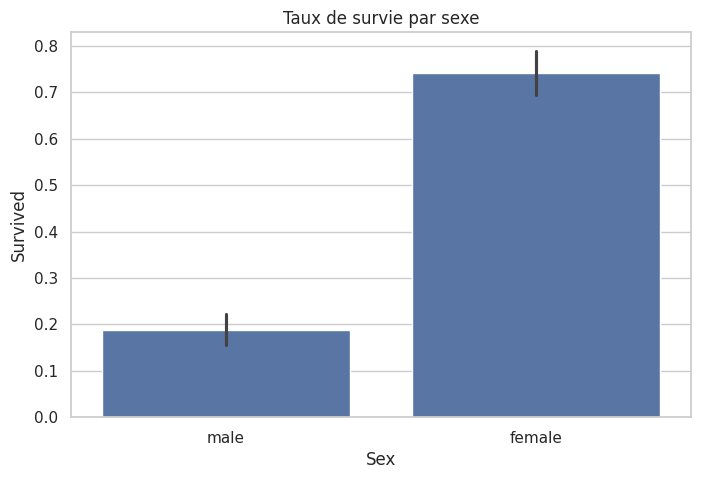

In [55]:
# Exercice 6 : premières visualisations combinées
# À compléter
plt.title("Taux de survie par sexe")
sns.barplot(x='Sex',y='Survived',data=df);




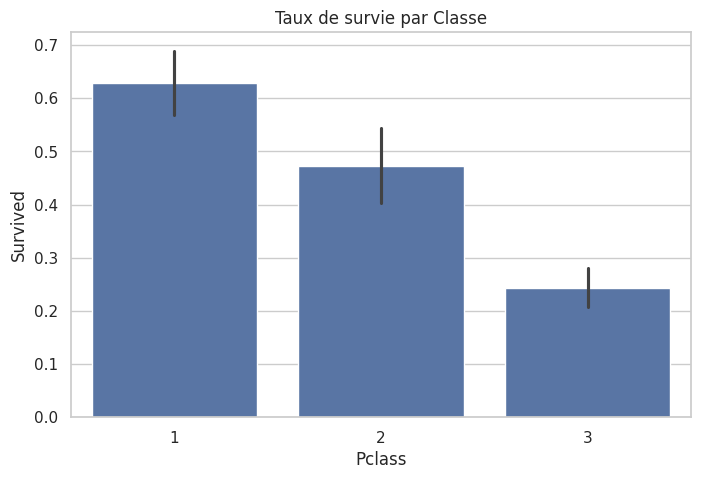

In [56]:
plt.title("Taux de survie par Classe")
sns.barplot(x='Pclass',y='Survived',data=df);


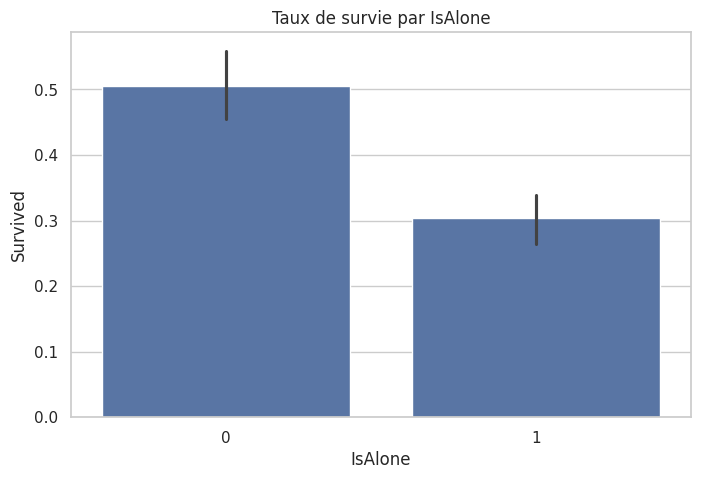

In [57]:
plt.title("Taux de survie par IsAlone")
sns.barplot(x='IsAlone',y='Survived',data=df);


## 7️ Mini-analyse

###  Exercice 7 — Interprétation des résultats

Rédigez quelques phrases (5 à 8) pour commenter vos résultats :

- Quels groupes semblent avoir le meilleur taux de survie ?  
- Avez-vous observé un lien entre la taille de la famille (`FamilySize` / `IsAlone`) et la survie ?  
- Une visualisation vous a-t-elle particulièrement surpris(e) ?

👉 Réponse à rédiger ci-dessous


*Écrivez ici votre mini-analyse sous forme de texte.*
Les groupes ayant les meilleurs taux de survie sont les femmes(74%), les passagers de la classe 1(62%) et les passagers qui ont de la famille (50%).

Le lien observé est que les individus seuls survivent moins que ceux ayant de la famille.

La visualisation surprenante est celle relative à celle de FamilySize/Alone. Il est étonnant que ceux qui sont seuls survivent moins que les autres. Il faudrait pousser l'analyse pour trouver les raisons qui justifient ce phénomène.